# Extension points: adapt an inventory run to your operation

A dairy buyer can place orders on **Mondays and Thursdays**. Products arrive the next day, suppliers ship whole cases, and a chiller has limited room. Later, a supplier unexpectedly cancels one order day and a stock count finds missing units.

We will add these rules one at a time. The policy requests quantities; a `DecisionSchedule` chooses *when* it may do so; an `OrderingConstraint` decides what can actually be ordered; dated callbacks represent exceptional events. `SimulationEngine` still handles receipts, demand, stock, backlog, and the event record.

This is an extension tutorial, not a forecast-accuracy or optimization study. Daily demand rates and all operating assumptions are declared below.

## 1. Start with one product and an irregular order calendar

The schedule uses **zero-based demand periods**: period 0 is Monday 2 March 2026. Its two methods answer whether an order is allowed now and when the next opportunity occurs. The manifest records the schedule in each run's settings.

In [2]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from stockcast import (
    ConstraintResult, DecisionSchedule, InventoryStateDataFrame, OrderDecision,
    OrderingConstraint, OrderingConstraints, OrderMultiple, ReorderPointPolicy,
    ScheduledInventoryAdjustment, ScheduledOrderHold, ShelfSpaceLimit, SimulationEngine,
)
from stockcast.evaluation import (
    CoverageMetric, InventoryEvaluator, backlog_unit_periods, capacity_violation_count,
    fill_rate, validate_event_frame,
)


def poisson_quantile(probability, mean):
    """Smallest k with P(Poisson(mean) <= k) >= probability."""
    k, pmf = 0, math.exp(-mean)
    cdf = pmf
    while cdf < probability:
        k += 1
        pmf *= mean / k
        cdf += pmf
    return k

In [3]:
@dataclass(frozen=True)
class WeekdaySchedule(DecisionSchedule):
    """Decide on fixed weekdays (Monday = 0), counted from the first demand date."""

    weekdays: tuple
    first_demand_date: pd.Timestamp

    def should_decide(self, period):
        return (self.first_demand_date + pd.Timedelta(days=period)).weekday() in self.weekdays

    def next_decision_period(self, period):
        return next(p for p in range(period + 1, period + 8) if self.should_decide(p))

    def to_manifest(self):
        return {
            "type": "weekday",
            "weekdays": list(self.weekdays),
            "first_demand_date": self.first_demand_date.isoformat(),
        }


origin = pd.Timestamp("2026-03-01")  # opening state, Sunday
schedule = WeekdaySchedule((0, 3), origin + pd.Timedelta(days=1))  # Mon, Thu

A Monday decision is followed by Thursday, three days later. A Thursday decision is followed by Monday, four days later. These gaps matter because an accepted order takes one more day to arrive.

In [4]:
lead = 1  # one daily demand period until an accepted order is usable
calendar = pd.DataFrame([
    {
        "order_day": origin + pd.Timedelta(days=p + 1),
        "period": p,
        "next_order_day": origin + pd.Timedelta(days=schedule.next_decision_period(p) + 1),
        "coverage_days": schedule.next_decision_period(p) - p + lead,
    }
    for p in range(14) if schedule.should_decide(p)
])
calendar

,order_day,period,next_order_day,coverage_days
0,2026-03-02,0,2026-03-05,4
1,2026-03-05,3,2026-03-09,5
2,2026-03-09,7,2026-03-12,4
3,2026-03-12,10,2026-03-16,5


## 2. Give the schedule dated targets

We use synthetic daily demand for three products. The model rates are known inputs to this illustration, while the realized demand is drawn once with a fixed seed. The opening stock, lead time, backorder rule, warm-up week, three scored weeks, and final settlement week are explicit. The first run will use only **milk**; we will add the other products later.

In [5]:
skus = ["milk", "yogurt", "cheese"]
rate = {"milk": 14.0, "yogurt": 6.0, "cheese": 2.5}  # units/day
pack = {"milk": 12.0, "yogurt": 8.0, "cheese": 6.0}  # units/case
space = {"milk": 108.0, "yogurt": 60.0, "cheese": 30.0}  # chiller units
opening_stock = {"milk": 40.0, "yogurt": 20.0, "cheese": 10.0}
alpha, seed = 0.95, 3
warmup, scoring, settlement = 7, 21, 7
n_periods = warmup + scoring + settlement

rng = np.random.default_rng(seed)
y = np.column_stack([rng.poisson(rate[sku], n_periods) for sku in skus]).astype(float)
demand = pd.DataFrame({
    "unique_id": np.tile(skus, n_periods),
    "period": np.repeat(np.arange(n_periods), len(skus)),
    "date": np.repeat(pd.date_range(origin + pd.Timedelta(days=1), periods=n_periods), len(skus)),
    "y": y.reshape(-1),
})

In [6]:
def opening_inventory(selected_skus):
    # The engine receives observed starting stock, dated one day before demand period 0.
    return InventoryStateDataFrame(
        selected_skus, max_lead_time=lead, allow_backorders=True,
    ).initialize_from_observed(
        pd.DataFrame({
            "unique_id": selected_skus,
            "stock": [opening_stock[sku] for sku in selected_skus],
        }),
        on_hand_column="stock", start_date=origin,
    )

opening_inventory(["milk"]).get_dataframe()[
    ["unique_id", "on_hand", "backorders", "in_transit", "date"]]

,unique_id,on_hand,backorders,in_transit,date
0,milk,40.0,0.0,[0.0],2026-03-01


Here is the demand path the runs will share. The vertical lines are order opportunities; they are **not** evidence that an order was placed. Later plots will use the event record to show actual requests, accepted orders, and receipts.

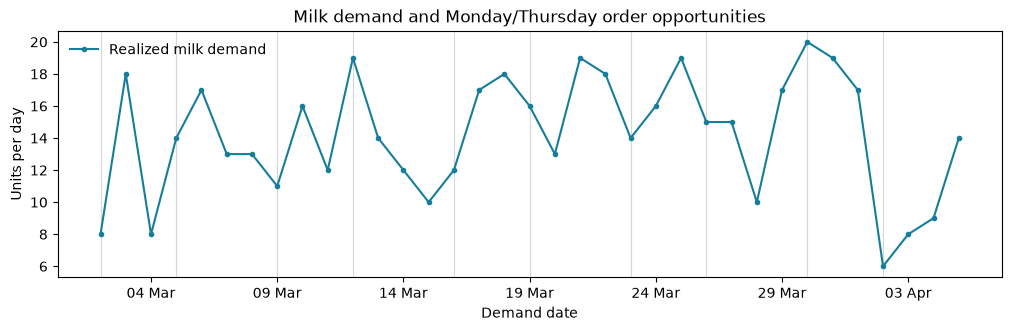

In [7]:
fig, ax = plt.subplots(figsize=(10, 3.2), layout="constrained")
milk_demand = demand.loc[demand["unique_id"].eq("milk")]
ax.plot(milk_demand["date"], milk_demand["y"], marker="o", markersize=3,
        color="#167d9a", label="Realized milk demand")
for p in range(n_periods):
    if schedule.should_decide(p):
        ax.axvline(origin + pd.Timedelta(days=p + 1), color="0.84", linewidth=0.8, zorder=0)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set(title="Milk demand and Monday/Thursday order opportunities",
       ylabel="Units per day", xlabel="Demand date")
ax.legend(frameon=False)
plt.show()

At a decision on period `t`, the next accepted order can arrive before demand at `u + L`, where `u` is the next opportunity. The reorder target therefore covers **`H = (u - t) + L` complete demand periods**: four days on Monday, five on Thursday. We calculate a *direct quantile of cumulative Poisson demand* over that window; we do not add daily quantiles.

`ReorderPointPolicy(policy_type="sS")` compares inventory position with `s` and, if needed, requests enough to reach `S`. Here `S = s + two days of mean demand` is a declared cycle-stock rule, **not** another quantile or a proven optimum. Each fitted snapshot carries its own information cutoff and target end date. `policy_schedule` will select the matching snapshot when its order day arrives.

In [8]:
decision_periods = [p for p in range(warmup + scoring) if schedule.should_decide(p)]


def fitted_snapshot(period, selected_skus):
    window = schedule.next_decision_period(period) - period + lead
    cutoff = origin + pd.Timedelta(days=period)  # last demand date known before today's decision
    s = [float(poisson_quantile(alpha, rate[sku] * window)) for sku in selected_skus]
    targets = pd.DataFrame({
        "unique_id": selected_skus,
        "reorder_q95": s,
        "order_up_to": [level + 2 * rate[sku] for level, sku in zip(s, selected_skus)],
        "window_end": cutoff + pd.Timedelta(days=window),
    })
    return ReorderPointPolicy(
        lead, schedule=schedule, policy_type="sS",
        service_level=alpha, allow_backorders=True,
    ).fit(
        targets, forecast_origin=cutoff, forecast_frequency="D",
        reorder_point_column="reorder_q95", order_up_to_column="order_up_to",
        reorder_end_date_column="window_end", reorder_horizon=window,
        target_source="external_direct", target_probability=alpha,
    )

In [9]:
# Display the first two dated targets before running any demand.
milk_snapshots = {p: fitted_snapshot(p, ["milk"]) for p in decision_periods}
pd.DataFrame([
    {
        "order_day": origin + pd.Timedelta(days=p + 1),
        "coverage_days": milk_snapshots[p].get_target_metadata()["reorder_horizon"],
        "s": milk_snapshots[p].get_reorder_points().iloc[0]["reorder_point"],
        "target_end": milk_snapshots[p].get_target_metadata()["reorder_end_date"],
    }
    for p in decision_periods[:2]
])

,order_day,coverage_days,s,target_end
0,2026-03-02,4,69.0,2026-03-05T00:00:00
1,2026-03-05,5,84.0,2026-03-09T00:00:00


## 3. Run milk through the engine

`SimulationEngine.run()` receives the dated demand table, an explicit opening state, and the fitted policies. The first policy is supplied directly; `policy_schedule` selects the dated snapshot at every order opportunity, including the first. The engine checks that snapshots occur on real decision days and that each target covers the schedule's window. We score only the middle three weeks; settlement demand still changes stock but has no new orders.

In [10]:
milk_run = SimulationEngine().run(
    milk_snapshots[decision_periods[0]],
    demand.loc[demand["unique_id"].eq("milk")].copy(),
    opening_inventory(["milk"]), n_periods,
    period_frequency="D", warmup_periods=warmup, scoring_periods=scoring,
    settlement_periods=settlement, order_during_settlement=False,
    demand_source_name="synthetic_dairy_poisson", random_seed=seed,
    policy_schedule=milk_snapshots,
)
milk_events = validate_event_frame(milk_run.to_event_frame())
assert milk_run.run_settings["decision_schedule"]["type"] == "weekday"
assert milk_run.run_settings["policy_update_periods"] == decision_periods

Read the first order and its following receipt from the validated event ledger. `order_quantity` is the accepted quantity placed on the order day; `received_units` is physical stock arriving later. `ending_on_hand` is measured **after that day's demand**. The two rows make the before-demand lead-time convention visible.

In [11]:
first_order = milk_events.loc[milk_events["order_quantity"].gt(0)].iloc[0]
receipt = milk_events.loc[
    milk_events["period"].eq(first_order["period"] + lead)
].iloc[0]
assert receipt["received_units"] == first_order["order_quantity"]
milk_events.loc[
    milk_events["period"].between(first_order["period"], first_order["period"] + lead),
    ["period", "date", "demand", "decision_inventory_position", "order_quantity",
     "received_units", "ending_on_hand", "backorders_end"],
]

,period,date,demand,decision_inventory_position,order_quantity,received_units,ending_on_hand,backorders_end
0,1,2026-03-02,8.0,40.0,57.0,0.0,32.0,0.0
1,2,2026-03-03,18.0,NaN,0.0,57.0,71.0,0.0


## 4. The same schedule can serve several products

Nothing in the schedule depends on an SKU. We now fit the same dated target logic for milk, yogurt, and cheese. The helper below repeats the **same** engine call for the later scenarios, always making a fresh opening state and replaying the same demand. Its arguments expose exactly what changes: constraints and callbacks.

In [12]:
snapshots = {p: fitted_snapshot(p, skus) for p in decision_periods}


def simulate(constraints=None, callbacks=None):
    return SimulationEngine().run(
        snapshots[decision_periods[0]], demand, opening_inventory(skus), n_periods,
        period_frequency="D", warmup_periods=warmup, scoring_periods=scoring,
        settlement_periods=settlement, order_during_settlement=False,
        demand_source_name="synthetic_dairy_poisson", random_seed=seed,
        policy_schedule=snapshots, order_constraints=constraints, callbacks=callbacks,
    )

baseline = simulate()
assert set(baseline.to_event_frame()["unique_id"]) == set(skus)

In [13]:
# A short target table shows why Thursday's reorder points are higher.
pd.DataFrame([
    {
        "order_day": origin + pd.Timedelta(days=p + 1),
        "coverage_days": snapshots[p].get_target_metadata()["reorder_horizon"],
        **snapshots[p].get_reorder_points().set_index("unique_id")["reorder_point"].to_dict(),
    }
    for p in decision_periods[:4]
])

,order_day,coverage_days,milk,yogurt,cheese
0,2026-03-02,4,69.0,32.0,15.0
1,2026-03-05,5,84.0,39.0,19.0
2,2026-03-09,4,69.0,32.0,15.0
3,2026-03-12,5,84.0,39.0,19.0


## 5. Add a rule for whole cases within chiller space

A policy's requested quantity may be operationally impossible. `OrderingConstraints` runs named rules between the policy and the physical order. The built-in `OrderMultiple` rounds *up* to a full case, while `ShelfSpaceLimit` clips to free capacity. When space binds, these separate adjustments can disagree. Stockcast validates the final combination and raises instead of silently accepting an impossible order.

In [14]:
try:
    simulate(OrderingConstraints([
        OrderMultiple(pack, mode="adjust"), ShelfSpaceLimit(space, mode="adjust"),
    ]))
    raise AssertionError("expected the built-in pair to conflict once space binds")
except ValueError as error:
    print(type(error).__name__ + ": " + str(error))

ValueError: final composed order for SKU milk violates order_multiple: 42.0 is not a multiple of 12.0; the declared constraint sequence did not produce a jointly feasible quantity


Our buyer's actual rule is: **round the request up to cases, then take only as many whole cases as will fit**. Free space excludes stock already on hand and units already in transit. First, express that quantity calculation as a small function; zero accepted cases is possible when the chiller is full.

In [15]:
def whole_cases_that_fit(requested, on_hand, in_transit, case_size, capacity):
    occupied = on_hand + in_transit
    free_cases = math.floor(max(0.0, capacity - occupied) / case_size + 1e-9)
    wanted_cases = math.ceil(requested / case_size - 1e-9)
    return float(min(wanted_cases, free_cases) * case_size)

# A 25-unit request would round to 36 milk units, but only 24 fit here.
assert whole_cases_that_fit(25, 80, 0, 12, 108) == 24

An `OrderingConstraint` receives the policy's `OrderDecision` and a defensive inventory view. Its `apply()` method returns a **new** decision and per-SKU audit rows. The engine records the requested quantity, final quantity, and whether capacity reduced the request. `to_manifest()` records the parameters so the run can be understood later.

In [16]:
class PackedShelfSpace(OrderingConstraint):
    """Round up to whole cases, then keep only cases that fit."""

    name = "packed_shelf_space"

    def __init__(self, pack, space):
        self.pack, self.space = dict(pack), dict(space)

    def apply(self, order, context):
        frame = order.get_dataframe()  # a copy of the policy request
        state = context.inventory.get_dataframe().set_index(context.inventory.sku_column)
        requested = frame["order_quantity"].to_numpy(dtype=float)
        accepted = []
        for sku, quantity in zip(frame[order.sku_column], requested):
            occupied = state.at[sku, "on_hand"]
            pipeline = float(np.sum(state.at[sku, "in_transit"]))
            accepted.append(whole_cases_that_fit(
                quantity, occupied, pipeline, self.pack[sku], self.space[sku],
            ))
        frame["order_quantity"] = accepted
        accepted = np.asarray(accepted)
        changed = ~np.isclose(requested, accepted)
        audit = pd.DataFrame({
            "unique_id": frame[order.sku_column],
            "requested_order_quantity": requested,
            "constrained_order_quantity": accepted,
            "constraint_adjustment_units": accepted - requested,
            "constraint_binding_flag": changed,
            "capacity_violation_flag": changed & (accepted < requested),
            "binding_constraints": [self.name if flag else "" for flag in changed],
        })
        adjusted = OrderDecision(
            frame, sku_column=order.sku_column,
            lead_time=order.lead_time, review_period=order.review_period,
        )
        return ConstraintResult(adjusted, audit)

    def to_manifest(self):
        return {**super().to_manifest(), "pack": self.pack, "space": self.space}

In [17]:
packed = simulate(OrderingConstraints([PackedShelfSpace(pack, space)]))
packed_events = validate_event_frame(packed.to_event_frame())
placed = packed_events.loc[packed_events["order_quantity"].gt(0)]
assert all((row.order_quantity / pack[row.unique_id]).is_integer()
           for row in placed.itertuples())
assert packed.run_settings["order_constraints"]["constraints"][0]["name"] == "packed_shelf_space"

Find the first time the rule changes a request. The policy's proposal and the accepted order appear **on the same event row**; the name identifies the rule that changed it. This is more useful than inferring a constraint from the later stock curve alone.

In [18]:
binding = packed_events.loc[packed_events["constraint_binding_flag"]].copy()
assert not binding.empty
binding[["date", "unique_id", "requested_order_quantity",
         "order_quantity", "constraint_adjustment_units",
         "capacity_violation_flag", "binding_constraints"]].head(8)

,date,unique_id,requested_order_quantity,order_quantity,constraint_adjustment_units,capacity_violation_flag,binding_constraints
0,2026-03-02,milk,57.0,60.0,3.0,False,packed_shelf_space
2,2026-03-02,cheese,10.0,12.0,2.0,False,packed_shelf_space
9,2026-03-05,milk,46.0,36.0,-10.0,True,packed_shelf_space
10,2026-03-05,yogurt,25.0,32.0,7.0,False,packed_shelf_space
11,2026-03-05,cheese,9.0,12.0,3.0,False,packed_shelf_space
21,2026-03-09,milk,52.0,60.0,8.0,False,packed_shelf_space
22,2026-03-09,yogurt,15.0,16.0,1.0,False,packed_shelf_space
30,2026-03-12,milk,46.0,36.0,-10.0,True,packed_shelf_space


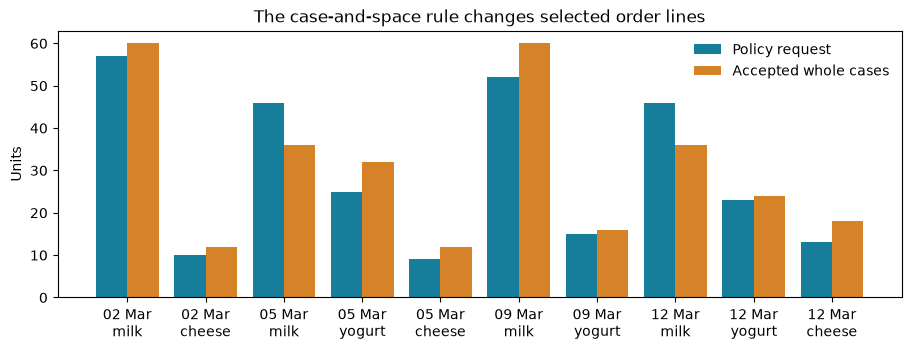

In [19]:
# Plot all changed decisions so readers can see rounding up and capacity cuts.
fig, ax = plt.subplots(figsize=(9, 3.4), layout="constrained")
shown = binding.head(10).reset_index(drop=True)
x = np.arange(len(shown))
ax.bar(x - 0.2, shown["requested_order_quantity"], width=0.4,
       color="#167d9a", label="Policy request")
ax.bar(x + 0.2, shown["order_quantity"], width=0.4,
       color="#d58228", label="Accepted whole cases")
ax.set_xticks(x, [f"{row.date:%d %b}\n{row.unique_id}" for row in shown.itertuples()])
ax.set(ylabel="Units", title="The case-and-space rule changes selected order lines")
ax.legend(frameon=False)
plt.show()

## 6. Add a one-day supplier disruption

Suppose the supplier announces on **Thursday 19 March**, after Monday's target was set, that it cannot accept Thursday's orders. `ScheduledOrderHold` sets those proposed quantities to zero **after prediction, before constraints**. It does not create another order opportunity or revise Monday's four-day target. If the closure had been known when Monday's target was constructed, we would remove Thursday from the decision schedule and fit a longer target instead.

In [20]:
holiday = pd.Timestamp("2026-03-19")
supplier_holiday = ScheduledOrderHold(pd.DataFrame({
    "unique_id": skus, "date": holiday,
    "reason": "supplier_disruption", "source": "supplier_notice",
}))
with_hold = simulate(
    OrderingConstraints([PackedShelfSpace(pack, space)]),
    callbacks=[supplier_holiday],
)
hold_audit = with_hold.to_callback_audit_frame()
hold_audit.loc[hold_audit["date"].eq(holiday),
               ["phase", "date", "unique_id", "before_value", "after_value", "reason"]]

,phase,date,unique_id,before_value,after_value,reason
0,on_after_prediction,2026-03-19,milk,52.0,0.0,supplier_disruption
1,on_after_prediction,2026-03-19,yogurt,24.0,0.0,supplier_disruption
2,on_after_prediction,2026-03-19,cheese,6.0,0.0,supplier_disruption


The audit reports the intervention, while the validated event rows show the physical consequence. On the disruption date a request may have existed, but no accepted order entered the pipeline for the affected products. The next Monday remains the next scheduled chance to order.

In [21]:
hold_events = validate_event_frame(with_hold.to_event_frame())
hold_events.loc[hold_events["date"].eq(holiday),
    ["date", "unique_id", "requested_order_quantity", "callback_adjusted_order_quantity",
     "order_quantity", "callback_adjustment_units"]]

,date,unique_id,requested_order_quantity,callback_adjusted_order_quantity,order_quantity,callback_adjustment_units
51,2026-03-19,milk,52.0,0.0,0.0,-52.0
52,2026-03-19,yogurt,24.0,0.0,0.0,-24.0
53,2026-03-19,cheese,6.0,0.0,0.0,-6.0


## 7. Add a stock-count correction

A count on **Friday 13 March**, after that day's demand, finds four fewer units of milk than the recorded on-hand quantity. `ScheduledInventoryAdjustment` proposes a signed change. The engine checks it, applies it, and writes both the callback audit and `inventory_adjustment_units` in the stock event. The next decision sees the corrected stock.

In [22]:
count_day = pd.Timestamp("2026-03-13")
cycle_count = ScheduledInventoryAdjustment(pd.DataFrame({
    "unique_id": ["milk"], "date": [count_day], "quantity_delta": [-4.0],
    "reason": ["stock_count_correction"], "source": ["cycle_count"],
}))
full = simulate(
    OrderingConstraints([PackedShelfSpace(pack, space)]),
    callbacks=[supplier_holiday, cycle_count],
)
full_audit = full.to_callback_audit_frame()
assert set(full_audit["reason"]) == {"supplier_disruption", "stock_count_correction"}
full_audit[["phase", "date", "unique_id", "before_value", "after_value", "reason"]]

,phase,date,unique_id,before_value,after_value,reason
0,on_after_demand,2026-03-13,milk,69.0,65.0,stock_count_correction
1,on_after_prediction,2026-03-19,milk,56.0,0.0,supplier_disruption
2,on_after_prediction,2026-03-19,yogurt,24.0,0.0,supplier_disruption
3,on_after_prediction,2026-03-19,cheese,6.0,0.0,supplier_disruption


In [23]:
full_events = validate_event_frame(full.to_event_frame())
count_row = full_events.loc[
    full_events["date"].eq(count_day) & full_events["unique_id"].eq("milk")
].iloc[0]
assert count_row["inventory_adjustment_units"] == -4.0
assert np.isclose(
    count_row["ending_on_hand"],
    count_row["starting_on_hand"] + count_row["received_units"]
    - count_row["fulfilled_units"] - count_row["expired_units"]
    + count_row["inventory_adjustment_units"],
)
full_events.loc[
    full_events["unique_id"].eq("milk")
    & full_events["date"].between(count_day - pd.Timedelta(days=1),
                                    count_day + pd.Timedelta(days=1)),
    ["date", "starting_on_hand", "received_units", "fulfilled_units",
     "inventory_adjustment_units", "ending_on_hand"],
]

,date,starting_on_hand,received_units,fulfilled_units,inventory_adjustment_units,ending_on_hand
30,2026-03-12,66.0,0.0,19.0,0.0,47.0
33,2026-03-13,47.0,36.0,14.0,-4.0,65.0
36,2026-03-14,65.0,0.0,12.0,0.0,53.0


## 8. Compare what each addition changed

The runs add rules **cumulatively** on the same demand and opening stock: schedule and targets → case-and-space constraint → supplier disruption → stock count. Compare adjacent rows to see the effect of each addition. `InventoryEvaluator` reads validated **scoring-window** events. Fill rate measures served demand units; backlog unit-periods counts how much backlog persisted over time. `CoverageMetric("trailing")` here is the mean of SKU-day stock-to-realized-rate ratios, as declared in its context. These are descriptive outcomes for this synthetic path, not universal operating recommendations.

In [24]:
runs = {
    "1. schedule + targets": baseline,
    "2. + packs and chiller": packed,
    "3. + supplier disruption": with_hold,
    "4. + stock count": full,
}
metrics = [fill_rate, backlog_unit_periods, capacity_violation_count,
           CoverageMetric("trailing")]
context = {"coverage_aggregation": "mean_of_sku_period_ratios"}
summary = pd.concat([
    InventoryEvaluator().fit(result, window="scoring")
    .evaluate(metrics, groupby=[], context=context)
    .assign(scenario=name, ordered_units=result.to_event_frame("scoring")["order_quantity"].sum())
    for name, result in runs.items()
]).set_index("scenario")
summary.round(3)

,fill_rate,backlog_unit_periods,capacity_violation_count,coverage_trailing,ordered_units
scenario,,,,,
1. schedule + targets,1.000,0.0,0,4.969,493.0
2. + packs and chiller,1.000,0.0,3,5.417,488.0
3. + supplier disruption,0.947,32.0,2,4.836,488.0
4. + stock count,0.939,40.0,2,4.772,488.0


In this replay, the case-and-space rule leaves fill rate at 1.000 while reducing three requests to fit capacity. The disruption lowers fill rate to 0.947 and creates 32 backlog unit-periods; adding the earlier stock-count correction lowers fill rate to 0.939 and raises backlog to 40. The branches are **counterfactual comparisons**: the count occurs on 13 March even though its branch is introduced after the 19 March disruption. `capacity_violation_count` counts requested order lines cut for capacity, not orders that overflowed the chiller. Total ordered units can stay the same while order timing and service change.

The following plot uses **end-of-day milk net stock** (`on hand − backlog`) so negative values show unmet demand still waiting. The thin lines mark scheduled order opportunities, the red line marks the canceled supplier day, and the dotted line marks the stock count. Settlement is shaded because no orders are allowed there and those rows are excluded from the summary. Read the plot together with the audit and event tables above: the line alone cannot tell you which extension caused a change.

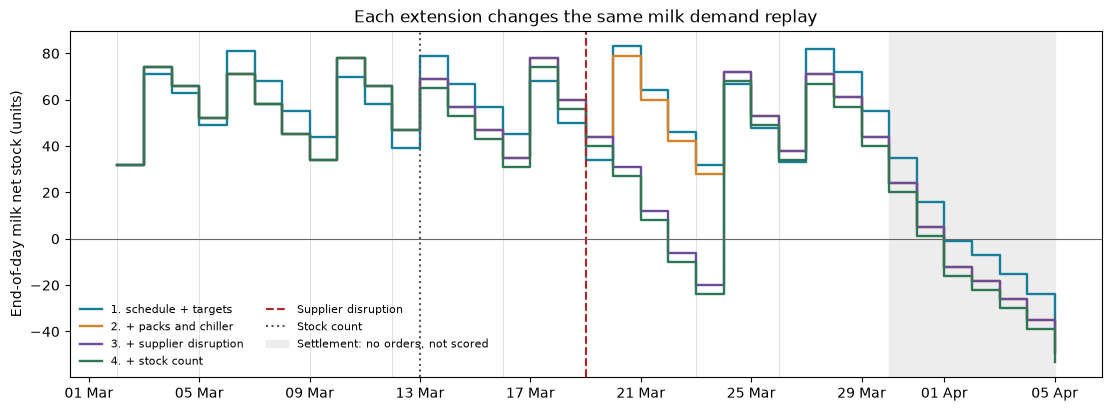

In [25]:
fig, ax = plt.subplots(figsize=(11, 4), layout="constrained")
colors = ["#167d9a", "#d58228", "#6b4c9a", "#2e7655"]
for (name, result), color in zip(runs.items(), colors):
    milk = result.to_event_frame().query("unique_id == 'milk'")
    ax.step(milk["date"], milk["ending_on_hand"] - milk["backorders_end"],
            where="post", label=name, color=color, linewidth=1.7)
for p in decision_periods:
    ax.axvline(origin + pd.Timedelta(days=p + 1), color="0.88", linewidth=0.7, zorder=0)
ax.axvline(holiday, color="#b22222", linestyle="--", label="Supplier disruption")
ax.axvline(count_day, color="#555555", linestyle=":", label="Stock count")
settlement_start = origin + pd.Timedelta(days=warmup + scoring + 1)
ax.axvspan(settlement_start, demand["date"].max(), color="0.93", zorder=-1,
           label="Settlement: no orders, not scored")
ax.axhline(0, color="0.4", linewidth=0.8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set(ylabel="End-of-day milk net stock (units)",
       title="Each extension changes the same milk demand replay")
ax.legend(frameon=False, fontsize=8, ncol=2)
plt.show()

## Use the extension that matches the operating fact

- A **schedule** declares repeatable order opportunities and changes the target window. If a closure is known during planning, encode it here and refit the affected targets.
- A **constraint** converts a policy request into a feasible order and leaves per-SKU evidence of every change. Write one when built-in rules cannot express a joint operational rule.
- A **scheduled callback** records a dated exception such as a late supplier cancellation or a stock correction. It changes the current order or stock at its defined phase; it does not rewrite the schedule or earlier information.
- An **inventory process** models a *recurring* physical flow, such as expiry, inspection discards or returns, at a defined period phase. Each flow is named and recorded in the ledger (`processes=[...]`; notebook 05e).

The package keeps its normal state transitions, event validation, and evaluation across all four runs. This example uses known Poisson demand rates; it does not evaluate forecast error, expiry, financial costs, or whether these policy levels are optimal. See Notebook 05 for a custom policy and Notebook 08 for writing a custom callback.